# Data Analysis, Exploration, and Visualization with Pandas

In [4]:
# importing important modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import requests 
import json
import re


## Data Loading or reading
We can load the data from a different format. We load it as a dataframe. 

What is dataframe? 

What is series? 


In [5]:
df = pd.read_csv('./weight-height.csv')

## Data Exploration
We will try to understand the data set.

In [6]:
df.columns

Index(['Gender', 'Height', 'Weight'], dtype='object')

In [7]:
list(df.columns)

['Gender', 'Height', 'Weight']

In [8]:
df.shape

(10000, 3)

In [9]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [10]:
df.head(10)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
6,Male,68.785081,183.927889
7,Male,68.348516,167.971110
8,Male,67.018950,175.929440
9,Male,63.456494,156.399676


In [11]:
df.tail()

,Gender,Height,Weight
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461
9999,Female,61.944246,113.649103


In [12]:
df.tail(10)

,Gender,Height,Weight
9990,Female,63.179498,141.266100
9991,Female,62.636675,102.853563
9992,Female,62.077832,138.691680
9993,Female,60.030434,97.687432
9994,Female,59.098250,110.529686
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461
9999,Female,61.944246,113.649103


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [14]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [15]:
df['Gender'].head()

0    Male
1    Male
2    Male
3    Male
4    Male
Name: Gender, dtype: object

In [16]:
df[['Height','Weight']].head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [17]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [18]:
# boolean index
df_male = df[df['Gender'] == 'Male']
df_male.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [19]:
df_female = df[df['Gender'] == 'Female']
df_female.head()

,Gender,Height,Weight
5000,Female,58.910732,102.088326
5001,Female,65.230013,141.305823
5002,Female,63.369004,131.041403
5003,Female,64.479997,128.171511
5004,Female,61.793096,129.781407


## Descriptive Statistics
- Central tendency: mean, median,mode
- Varience, STD
- min, max


In [20]:
df_male.describe()

,Height,Weight
count,5000.000000,5000.000000
mean,69.026346,187.020621
std,2.863362,19.781155
min,58.406905,112.902939
25%,67.174679,173.887767
50%,69.027709,187.033546
75%,70.988744,200.357802
max,78.998742,269.989699


In [21]:
df_female.describe()

,Height,Weight
count,5000.000000,5000.000000
mean,63.708774,135.860093
std,2.696284,19.022468
min,54.263133,64.700127
25%,61.894441,122.934096
50%,63.730924,136.117583
75%,65.563565,148.810926
max,73.389586,202.237214


In [22]:
male_height = df_male['Height']
female_height = df_female['Height']

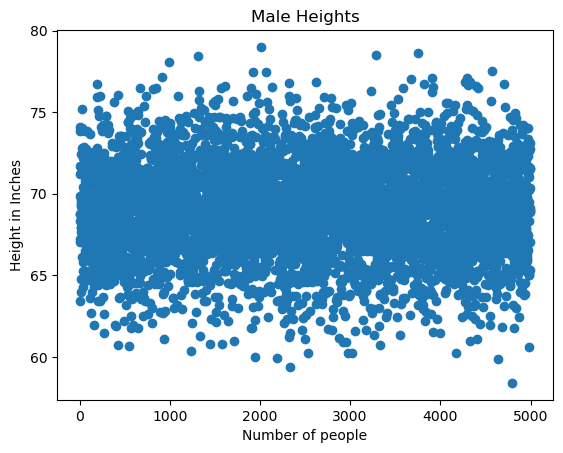

In [23]:
plt.scatter(np.arange(len(male_height)), male_height)
plt.title('Male Heights')
plt.xlabel('Number of people')
plt.ylabel('Height in Inches')
plt.show()

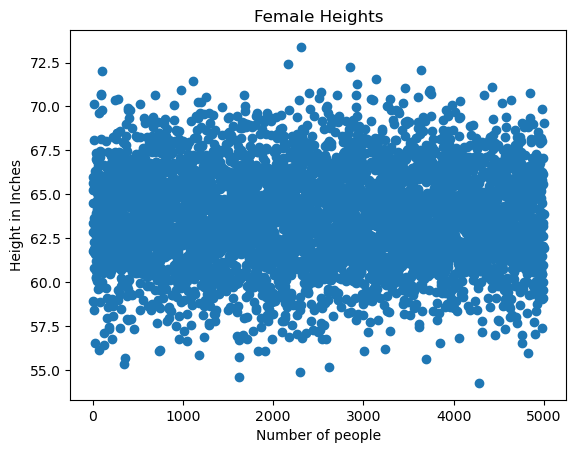

In [24]:
plt.scatter(np.arange(len(female_height)), female_height)
plt.title('Female Heights')
plt.xlabel('Number of people')
plt.ylabel('Height in Inches')
plt.show()

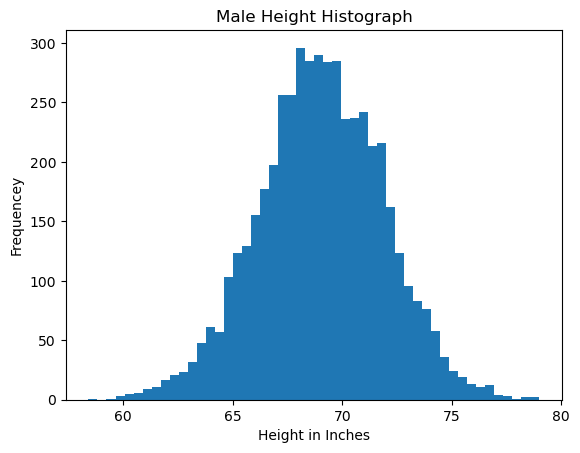

In [25]:
plt.hist(male_height, bins=50)
plt.title('Male Height Histograph')
plt.xlabel('Height in Inches')
plt.ylabel('Frequencey')
plt.show()

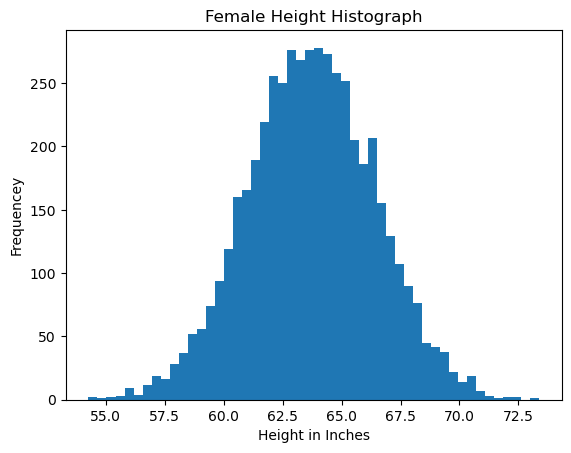

In [26]:
plt.hist(female_height, bins=50)
plt.title('Female Height Histograph')
plt.xlabel('Height in Inches')
plt.ylabel('Frequencey')
plt.show()

In [27]:
df_male[['Height', 'Weight']].corr()

,Height,Weight
Height,1.000000,0.862979
Weight,0.862979,1.000000


In [28]:
df_female[['Height', 'Weight']].corr()

,Height,Weight
Height,1.000000,0.849609
Weight,0.849609,1.000000


In [29]:
def fetch_data(url):
  response = requests.get(url)
  data = response.json()
  return data


url = 'https://api.thecatapi.com/v1/breeds'
data = fetch_data(url)

In [30]:
df_cat = pd.DataFrame(data)

In [31]:
df_cat.head()

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,natural,rare,rex,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability
0,"{'imperial': '7 - 10', 'metric': '3 - 5'}",abys,Abyssinian,None,http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx,http://www.vetstreet.com/cats/abyssinian,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Energetic, Independent, Intelligent, G...",Egypt,EG,...,1,0,0,0,0,https://en.wikipedia.org/wiki/Abyssinian_(cat),0,0XYvRd7oD,NaN,NaN
1,"{'imperial': '7 - 10', 'metric': '3 - 5'}",aege,Aegean,None,NaN,http://www.vetstreet.com/cats/aegean-cat,NaN,"Affectionate, Social, Intelligent, Playful, Ac...",Greece,GR,...,0,0,0,0,0,https://en.wikipedia.org/wiki/Aegean_cat,0,ozEvzdVM-,NaN,NaN
2,"{'imperial': '7 - 16', 'metric': '3 - 7'}",abob,American Bobtail,None,http://cfa.org/Breeds/BreedsAB/AmericanBobtail...,http://www.vetstreet.com/cats/american-bobtail,https://vcahospitals.com/know-your-pet/cat-bre...,"Intelligent, Interactive, Lively, Playful, Sen...",United States,US,...,0,0,0,1,0,https://en.wikipedia.org/wiki/American_Bobtail,0,hBXicehMA,NaN,NaN
3,"{'imperial': '5 - 10', 'metric': '2 - 5'}",acur,American Curl,None,http://cfa.org/Breeds/BreedsAB/AmericanCurl.aspx,http://www.vetstreet.com/cats/american-curl,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Curious, Intelligent, Interactiv...",United States,US,...,0,0,0,0,0,https://en.wikipedia.org/wiki/American_Curl,0,xnsqonbjW,NaN,NaN
4,"{'imperial': '8 - 15', 'metric': '4 - 7'}",asho,American Shorthair,None,http://cfa.org/Breeds/BreedsAB/AmericanShortha...,http://www.vetstreet.com/cats/american-shorthair,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Curious, Easy Going, Playful, Calm",United States,US,...,1,0,0,0,0,https://en.wikipedia.org/wiki/American_Shorthair,0,JFPROfGtQ,NaN,NaN


In [32]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   weight              67 non-null     object 
 1   id                  67 non-null     object 
 2   name                67 non-null     object 
 3   breed_group         0 non-null      object 
 4   cfa_url             43 non-null     object 
 5   vetstreet_url       50 non-null     object 
 6   vcahospitals_url    42 non-null     object 
 7   temperament         67 non-null     object 
 8   origin              67 non-null     object 
 9   country_codes       67 non-null     object 
 10  country_code        67 non-null     object 
 11  description         67 non-null     object 
 12  life_span           67 non-null     object 
 13  indoor              67 non-null     int64  
 14  lap                 47 non-null     float64
 15  alt_names           63 non-null     object 
 16  adaptabili

In [33]:
df_cat[df_cat['reference_image_id'].isna()]

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,natural,rare,rex,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability
30,"{'imperial': '7 - 14', 'metric': '3 - 6'}",ebur,European Burmese,None,http://cfa.org/Breeds/BreedsCJ/EuropeanBurmese...,NaN,NaN,"Sweet, Affectionate, Loyal",Burma,MM,...,0,0,0,0,0,NaN,0,NaN,4.0,NaN
41,"{'imperial': '6 - 13', 'metric': '3 - 6'}",mala,Malayan,None,NaN,NaN,NaN,"Affectionate, Interactive, Playful, Social",United Kingdom,GB,...,0,0,0,0,0,https://en.wikipedia.org/wiki/Asian_cat,0,NaN,NaN,NaN


In [34]:
url = 'https://upload.wikimedia.org/wikipedia/commons/5/5c/British_burmese_-_Andel_Alois_at_Cat_show.JPG'

In [35]:
names = list(df_cat[df_cat['reference_image_id'].isna()]['name'].values)
print(names)

['European Burmese', 'Malayan']


In [36]:
df_cat.head()

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,natural,rare,rex,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability
0,"{'imperial': '7 - 10', 'metric': '3 - 5'}",abys,Abyssinian,None,http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx,http://www.vetstreet.com/cats/abyssinian,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Energetic, Independent, Intelligent, G...",Egypt,EG,...,1,0,0,0,0,https://en.wikipedia.org/wiki/Abyssinian_(cat),0,0XYvRd7oD,NaN,NaN
1,"{'imperial': '7 - 10', 'metric': '3 - 5'}",aege,Aegean,None,NaN,http://www.vetstreet.com/cats/aegean-cat,NaN,"Affectionate, Social, Intelligent, Playful, Ac...",Greece,GR,...,0,0,0,0,0,https://en.wikipedia.org/wiki/Aegean_cat,0,ozEvzdVM-,NaN,NaN
2,"{'imperial': '7 - 16', 'metric': '3 - 7'}",abob,American Bobtail,None,http://cfa.org/Breeds/BreedsAB/AmericanBobtail...,http://www.vetstreet.com/cats/american-bobtail,https://vcahospitals.com/know-your-pet/cat-bre...,"Intelligent, Interactive, Lively, Playful, Sen...",United States,US,...,0,0,0,1,0,https://en.wikipedia.org/wiki/American_Bobtail,0,hBXicehMA,NaN,NaN
3,"{'imperial': '5 - 10', 'metric': '2 - 5'}",acur,American Curl,None,http://cfa.org/Breeds/BreedsAB/AmericanCurl.aspx,http://www.vetstreet.com/cats/american-curl,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Curious, Intelligent, Interactiv...",United States,US,...,0,0,0,0,0,https://en.wikipedia.org/wiki/American_Curl,0,xnsqonbjW,NaN,NaN
4,"{'imperial': '8 - 15', 'metric': '4 - 7'}",asho,American Shorthair,None,http://cfa.org/Breeds/BreedsAB/AmericanShortha...,http://www.vetstreet.com/cats/american-shorthair,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Curious, Easy Going, Playful, Calm",United States,US,...,1,0,0,0,0,https://en.wikipedia.org/wiki/American_Shorthair,0,JFPROfGtQ,NaN,NaN


In [37]:
averages = []
for life_span in df_cat['life_span']:
    lowest, highest = life_span.split(' - ')
    average = (int(lowest) + int(highest)) / 2
    averages.append(average)
    print(average)

14.5
10.5
13.0
14.0
16.0
16.0
13.0
14.0
12.5
13.0
13.5
14.5
14.0
13.0
14.5
15.5
12.5
12.0
15.0
13.5
13.0
13.0
14.0
12.5
11.0
13.5
12.5
13.5
13.5
19.0
12.5
13.5
12.5
12.0
15.0
11.0
11.0
12.5
17.5
12.5
13.5
15.0
13.0
12.5
13.5
14.0
13.0
13.0
14.5
14.5
14.0
14.5
13.0
18.5
12.5
14.5
13.5
13.5
13.5
16.5
14.0
13.0
15.0
13.5
16.5
14.5
14.0


In [38]:
df_cat.columns

Index(['weight', 'id', 'name', 'breed_group', 'cfa_url', 'vetstreet_url',
       'vcahospitals_url', 'temperament', 'origin', 'country_codes',
       'country_code', 'description', 'life_span', 'indoor', 'lap',
       'alt_names', 'adaptability', 'affection_level', 'child_friendly',
       'dog_friendly', 'energy_level', 'grooming', 'health_issues',
       'intelligence', 'shedding_level', 'social_needs', 'stranger_friendly',
       'vocalisation', 'experimental', 'hairless', 'natural', 'rare', 'rex',
       'suppressed_tail', 'short_legs', 'wikipedia_url', 'hypoallergenic',
       'reference_image_id', 'cat_friendly', 'bidability'],
      dtype='object')

In [39]:
df_cat.shape

(67, 40)

In [40]:
averages

[14.5,
 10.5,
 13.0,
 14.0,
 16.0,
 16.0,
 13.0,
 14.0,
 12.5,
 13.0,
 13.5,
 14.5,
 14.0,
 13.0,
 14.5,
 15.5,
 12.5,
 12.0,
 15.0,
 13.5,
 13.0,
 13.0,
 14.0,
 12.5,
 11.0,
 13.5,
 12.5,
 13.5,
 13.5,
 19.0,
 12.5,
 13.5,
 12.5,
 12.0,
 15.0,
 11.0,
 11.0,
 12.5,
 17.5,
 12.5,
 13.5,
 15.0,
 13.0,
 12.5,
 13.5,
 14.0,
 13.0,
 13.0,
 14.5,
 14.5,
 14.0,
 14.5,
 13.0,
 18.5,
 12.5,
 14.5,
 13.5,
 13.5,
 13.5,
 16.5,
 14.0,
 13.0,
 15.0,
 13.5,
 16.5,
 14.5,
 14.0]

In [41]:
df_cat['life_span_average'] = averages

In [42]:
df_cat

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,rare,rex,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability,life_span_average
0,"{'imperial': '7 - 10', 'metric': '3 - 5'}",abys,Abyssinian,None,http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx,http://www.vetstreet.com/cats/abyssinian,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Energetic, Independent, Intelligent, G...",Egypt,EG,...,0,0,0,0,https://en.wikipedia.org/wiki/Abyssinian_(cat),0,0XYvRd7oD,NaN,NaN,14.5
1,"{'imperial': '7 - 10', 'metric': '3 - 5'}",aege,Aegean,None,NaN,http://www.vetstreet.com/cats/aegean-cat,NaN,"Affectionate, Social, Intelligent, Playful, Ac...",Greece,GR,...,0,0,0,0,https://en.wikipedia.org/wiki/Aegean_cat,0,ozEvzdVM-,NaN,NaN,10.5
2,"{'imperial': '7 - 16', 'metric': '3 - 7'}",abob,American Bobtail,None,http://cfa.org/Breeds/BreedsAB/AmericanBobtail...,http://www.vetstreet.com/cats/american-bobtail,https://vcahospitals.com/know-your-pet/cat-bre...,"Intelligent, Interactive, Lively, Playful, Sen...",United States,US,...,0,0,1,0,https://en.wikipedia.org/wiki/American_Bobtail,0,hBXicehMA,NaN,NaN,13.0
3,"{'imperial': '5 - 10', 'metric': '2 - 5'}",acur,American Curl,None,http://cfa.org/Breeds/BreedsAB/AmericanCurl.aspx,http://www.vetstreet.com/cats/american-curl,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Curious, Intelligent, Interactiv...",United States,US,...,0,0,0,0,https://en.wikipedia.org/wiki/American_Curl,0,xnsqonbjW,NaN,NaN,14.0
4,"{'imperial': '8 - 15', 'metric': '4 - 7'}",asho,American Shorthair,None,http://cfa.org/Breeds/BreedsAB/AmericanShortha...,http://www.vetstreet.com/cats/american-shorthair,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Curious, Easy Going, Playful, Calm",United States,US,...,0,0,0,0,https://en.wikipedia.org/wiki/American_Shorthair,0,JFPROfGtQ,NaN,NaN,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,"{'imperial': '6 - 12', 'metric': '3 - 5'}",tonk,Tonkinese,None,http://cfa.org/Breeds/BreedsSthruT/Tonkinese.aspx,http://www.vetstreet.com/cats/tonkinese,https://vcahospitals.com/know-your-pet/cat-bre...,"Curious, Intelligent, Social, Lively, Outgoing...",Canada,CA,...,0,0,0,0,https://en.wikipedia.org/wiki/Tonkinese_(cat),0,KBroiVNCM,NaN,NaN,15.0
63,"{'imperial': '7 - 15', 'metric': '3 - 7'}",toyg,Toyger,None,NaN,http://www.vetstreet.com/cats/toyger,NaN,"Playful, Social, Intelligent",United States,US,...,0,0,0,0,https://en.wikipedia.org/wiki/Toyger,0,O3F3_S1XN,NaN,NaN,13.5
64,"{'imperial': '5 - 10', 'metric': '2 - 5'}",tang,Turkish Angora,None,http://cfa.org/Breeds/BreedsSthruT/TurkishAngo...,http://www.vetstreet.com/cats/turkish-angora,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Agile, Clever, Gentle, Intellige...",Turkey,TR,...,0,0,0,0,https://en.wikipedia.org/wiki/Turkish_Angora,0,7CGV6WVXq,NaN,NaN,16.5
65,"{'imperial': '7 - 20', 'metric': '3 - 9'}",tvan,Turkish Van,None,http://cfa.org/Breeds/BreedsSthruT/TurkishVan....,http://www.vetstreet.com/cats/turkish-van,https://vcahospitals.com/know-your-pet/cat-bre...,"Agile, Intelligent, Loyal, Playful, Energetic",Turkey,TR,...,0,0,0,0,https://en.wikipedia.org/wiki/Turkish_Van,0,sxIXJax6h,NaN,NaN,14.5


In [43]:
# Filter out cats that live more than the average life span (13.7)

df_cat[df_cat['life_span_average'] > 18]


,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,rare,rex,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability,life_span_average
29,"{'imperial': '6 - 14', 'metric': '3 - 6'}",emau,Egyptian Mau,None,http://cfa.org/Breeds/BreedsCJ/EgyptianMau.aspx,http://www.vetstreet.com/cats/egyptian-mau,https://vcahospitals.com/know-your-pet/cat-bre...,"Agile, Dependent, Gentle, Intelligent, Lively,...",Egypt,EG,...,0,0,0,0,https://en.wikipedia.org/wiki/Egyptian_Mau,0,TuSyTkt2n,NaN,NaN,19.0
53,"{'imperial': '8 - 25', 'metric': '4 - 11'}",sava,Savannah,None,NaN,http://www.vetstreet.com/cats/savannah,NaN,"Curious, Social, Intelligent, Loyal, Outgoing,...",United States,US,...,0,0,0,0,https://en.wikipedia.org/wiki/Savannah_cat,0,a8nIYvs6S,NaN,NaN,18.5


In [44]:
weights = []
for weight in df_cat['weight']:
    lowest, highest = weight['metric'].split(' - ')
    average = (int(lowest) + int(highest)) / 2
    weights.append(average)
print(weights)

df_cat['weight_average'] = weights

[4.0, 4.0, 5.0, 3.5, 5.5, 5.5, 5.5, 5.0, 3.5, 3.0, 5.0, 5.0, 4.0, 6.0, 7.0, 4.0, 4.5, 6.0, 4.0, 5.0, 5.0, 5.5, 3.5, 3.0, 5.0, 5.5, 3.5, 5.5, 5.0, 4.5, 4.5, 4.5, 4.0, 4.5, 3.5, 3.5, 5.0, 4.0, 5.5, 4.0, 6.5, 4.5, 4.5, 3.0, 4.0, 5.5, 5.0, 3.5, 5.0, 6.0, 6.5, 7.0, 3.5, 7.5, 3.5, 5.0, 5.5, 5.5, 3.0, 4.0, 4.0, 4.0, 4.0, 5.0, 3.5, 6.0, 6.5]


In [45]:
df_cat.head()

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,rex,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability,life_span_average,weight_average
0,"{'imperial': '7 - 10', 'metric': '3 - 5'}",abys,Abyssinian,None,http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx,http://www.vetstreet.com/cats/abyssinian,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Energetic, Independent, Intelligent, G...",Egypt,EG,...,0,0,0,https://en.wikipedia.org/wiki/Abyssinian_(cat),0,0XYvRd7oD,NaN,NaN,14.5,4.0
1,"{'imperial': '7 - 10', 'metric': '3 - 5'}",aege,Aegean,None,NaN,http://www.vetstreet.com/cats/aegean-cat,NaN,"Affectionate, Social, Intelligent, Playful, Ac...",Greece,GR,...,0,0,0,https://en.wikipedia.org/wiki/Aegean_cat,0,ozEvzdVM-,NaN,NaN,10.5,4.0
2,"{'imperial': '7 - 16', 'metric': '3 - 7'}",abob,American Bobtail,None,http://cfa.org/Breeds/BreedsAB/AmericanBobtail...,http://www.vetstreet.com/cats/american-bobtail,https://vcahospitals.com/know-your-pet/cat-bre...,"Intelligent, Interactive, Lively, Playful, Sen...",United States,US,...,0,1,0,https://en.wikipedia.org/wiki/American_Bobtail,0,hBXicehMA,NaN,NaN,13.0,5.0
3,"{'imperial': '5 - 10', 'metric': '2 - 5'}",acur,American Curl,None,http://cfa.org/Breeds/BreedsAB/AmericanCurl.aspx,http://www.vetstreet.com/cats/american-curl,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Curious, Intelligent, Interactiv...",United States,US,...,0,0,0,https://en.wikipedia.org/wiki/American_Curl,0,xnsqonbjW,NaN,NaN,14.0,3.5
4,"{'imperial': '8 - 15', 'metric': '4 - 7'}",asho,American Shorthair,None,http://cfa.org/Breeds/BreedsAB/AmericanShortha...,http://www.vetstreet.com/cats/american-shorthair,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Curious, Easy Going, Playful, Calm",United States,US,...,0,0,0,https://en.wikipedia.org/wiki/American_Shorthair,0,JFPROfGtQ,NaN,NaN,16.0,5.5


In [46]:
df_cat[['id','name',  'origin', 'life_span_average', 'weight_average', 'description','reference_image_id']]

,id,name,origin,life_span_average,weight_average,description,reference_image_id
0,abys,Abyssinian,Egypt,14.5,4.0,"The Abyssinian is easy to care for, and a joy ...",0XYvRd7oD
1,aege,Aegean,Greece,10.5,4.0,Native to the Greek islands known as the Cycla...,ozEvzdVM-
2,abob,American Bobtail,United States,13.0,5.0,American Bobtails are loving and incredibly in...,hBXicehMA
3,acur,American Curl,United States,14.0,3.5,Distinguished by truly unique ears that curl b...,xnsqonbjW
4,asho,American Shorthair,United States,16.0,5.5,The American Shorthair is known for its longev...,JFPROfGtQ
...,...,...,...,...,...,...,...
62,tonk,Tonkinese,Canada,15.0,4.0,"Intelligent and generous with their affection,...",KBroiVNCM
63,toyg,Toyger,United States,13.5,5.0,"The Toyger has a sweet, calm personality and i...",O3F3_S1XN
64,tang,Turkish Angora,Turkey,16.5,3.5,This is a smart and intelligent cat which bond...,7CGV6WVXq
65,tvan,Turkish Van,Turkey,14.5,6.0,"While the Turkish Van loves to jump and climb,...",sxIXJax6h


In [47]:
import math
urls = []
for id in df_cat['reference_image_id']:
    if isinstance(id, float) and math.isnan(id):
        url = ""
        urls.append(url)
    else:
        url =  f"https://cdn2.thecatapi.com/images/{id}.jpg"
        urls.append(url)

        

In [48]:
urls

['https://cdn2.thecatapi.com/images/0XYvRd7oD.jpg',
 'https://cdn2.thecatapi.com/images/ozEvzdVM-.jpg',
 'https://cdn2.thecatapi.com/images/hBXicehMA.jpg',
 'https://cdn2.thecatapi.com/images/xnsqonbjW.jpg',
 'https://cdn2.thecatapi.com/images/JFPROfGtQ.jpg',
 'https://cdn2.thecatapi.com/images/8D--jCd21.jpg',
 'https://cdn2.thecatapi.com/images/k71ULYfRr.jpg',
 'https://cdn2.thecatapi.com/images/_6x-3TiCA.jpg',
 'https://cdn2.thecatapi.com/images/13MkvUreZ.jpg',
 'https://cdn2.thecatapi.com/images/5AdhMjeEu.jpg',
 'https://cdn2.thecatapi.com/images/O3btzLlsO.jpg',
 'https://cdn2.thecatapi.com/images/HOrX5gwLS.jpg',
 'https://cdn2.thecatapi.com/images/5iYq9NmT1.jpg',
 'https://cdn2.thecatapi.com/images/7isAO4Cav.jpg',
 'https://cdn2.thecatapi.com/images/s4wQfYoEk.jpg',
 'https://cdn2.thecatapi.com/images/4lXnnfxac.jpg',
 'https://cdn2.thecatapi.com/images/jvg3XfEdC.jpg',
 'https://cdn2.thecatapi.com/images/B1ERTmgph.jpg',
 'https://cdn2.thecatapi.com/images/TR-5nAd_S.jpg',
 'https://cd

In [49]:
df_cat['image_url']= urls

In [50]:
df_cat.head()

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability,life_span_average,weight_average,image_url
0,"{'imperial': '7 - 10', 'metric': '3 - 5'}",abys,Abyssinian,None,http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx,http://www.vetstreet.com/cats/abyssinian,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Energetic, Independent, Intelligent, G...",Egypt,EG,...,0,0,https://en.wikipedia.org/wiki/Abyssinian_(cat),0,0XYvRd7oD,NaN,NaN,14.5,4.0,https://cdn2.thecatapi.com/images/0XYvRd7oD.jpg
1,"{'imperial': '7 - 10', 'metric': '3 - 5'}",aege,Aegean,None,NaN,http://www.vetstreet.com/cats/aegean-cat,NaN,"Affectionate, Social, Intelligent, Playful, Ac...",Greece,GR,...,0,0,https://en.wikipedia.org/wiki/Aegean_cat,0,ozEvzdVM-,NaN,NaN,10.5,4.0,https://cdn2.thecatapi.com/images/ozEvzdVM-.jpg
2,"{'imperial': '7 - 16', 'metric': '3 - 7'}",abob,American Bobtail,None,http://cfa.org/Breeds/BreedsAB/AmericanBobtail...,http://www.vetstreet.com/cats/american-bobtail,https://vcahospitals.com/know-your-pet/cat-bre...,"Intelligent, Interactive, Lively, Playful, Sen...",United States,US,...,1,0,https://en.wikipedia.org/wiki/American_Bobtail,0,hBXicehMA,NaN,NaN,13.0,5.0,https://cdn2.thecatapi.com/images/hBXicehMA.jpg
3,"{'imperial': '5 - 10', 'metric': '2 - 5'}",acur,American Curl,None,http://cfa.org/Breeds/BreedsAB/AmericanCurl.aspx,http://www.vetstreet.com/cats/american-curl,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Curious, Intelligent, Interactiv...",United States,US,...,0,0,https://en.wikipedia.org/wiki/American_Curl,0,xnsqonbjW,NaN,NaN,14.0,3.5,https://cdn2.thecatapi.com/images/xnsqonbjW.jpg
4,"{'imperial': '8 - 15', 'metric': '4 - 7'}",asho,American Shorthair,None,http://cfa.org/Breeds/BreedsAB/AmericanShortha...,http://www.vetstreet.com/cats/american-shorthair,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Curious, Easy Going, Playful, Calm",United States,US,...,0,0,https://en.wikipedia.org/wiki/American_Shorthair,0,JFPROfGtQ,NaN,NaN,16.0,5.5,https://cdn2.thecatapi.com/images/JFPROfGtQ.jpg


In [51]:
df_minfied_cats = df_cat[['id','name',  'origin', 'life_span_average', 'weight_average', 'description','image_url']]

In [52]:
df_minfied_cats[['id','name',  'origin', 'life_span_average', 'weight_average', 'description','image_url']].to_csv('minifed_cats.csv')

In [53]:
df_minfied_cats[df_minfied_cats['image_url'] == '']

,id,name,origin,life_span_average,weight_average,description,image_url
30,ebur,European Burmese,Burma,12.5,4.5,"The European Burmese is a very affectionate, i...",
41,mala,Malayan,United Kingdom,15.0,4.5,Malayans love to explore and even enjoy travel...,


In [54]:
url = 'https://upload.wikimedia.org/wikipedia/commons/5/5c/British_burmese_-_Andel_Alois_at_Cat_show.JPG' 
url_malayan = 'https://images.unsplash.com/photo-1535268647677-300dbf3d78d1?w=800'

In [55]:
df_minfied_cats[['id','name',  'origin', 'life_span_average', 'weight_average', 'description','image_url']].to_json('minifed_cats.json')

In [56]:
import json

In [57]:

data = json.loads(df_minfied_cats.to_json(orient="records"))

In [58]:
with open('./cats.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

In [59]:
# ETL => 
# We may inject the data to where? database

'''

We have a website the shows the prices of electronics:
ebay
alibaba
amazon

Scrape the data from the three websites

'''

'\n\nWe have a website the shows the prices of electronics:\nebay\nalibaba\namazon\n\nScrape the data from the three websites\n\n'

In [60]:
df_minfied_cats

,id,name,origin,life_span_average,weight_average,description,image_url
0,abys,Abyssinian,Egypt,14.5,4.0,"The Abyssinian is easy to care for, and a joy ...",https://cdn2.thecatapi.com/images/0XYvRd7oD.jpg
1,aege,Aegean,Greece,10.5,4.0,Native to the Greek islands known as the Cycla...,https://cdn2.thecatapi.com/images/ozEvzdVM-.jpg
2,abob,American Bobtail,United States,13.0,5.0,American Bobtails are loving and incredibly in...,https://cdn2.thecatapi.com/images/hBXicehMA.jpg
3,acur,American Curl,United States,14.0,3.5,Distinguished by truly unique ears that curl b...,https://cdn2.thecatapi.com/images/xnsqonbjW.jpg
4,asho,American Shorthair,United States,16.0,5.5,The American Shorthair is known for its longev...,https://cdn2.thecatapi.com/images/JFPROfGtQ.jpg
...,...,...,...,...,...,...,...
62,tonk,Tonkinese,Canada,15.0,4.0,"Intelligent and generous with their affection,...",https://cdn2.thecatapi.com/images/KBroiVNCM.jpg
63,toyg,Toyger,United States,13.5,5.0,"The Toyger has a sweet, calm personality and i...",https://cdn2.thecatapi.com/images/O3F3_S1XN.jpg
64,tang,Turkish Angora,Turkey,16.5,3.5,This is a smart and intelligent cat which bond...,https://cdn2.thecatapi.com/images/7CGV6WVXq.jpg
65,tvan,Turkish Van,Turkey,14.5,6.0,"While the Turkish Van loves to jump and climb,...",https://cdn2.thecatapi.com/images/sxIXJax6h.jpg


In [61]:
"""
european_burmese = 'https://platopettreats.com/cdn/shop/articles/the-rare-european-burmese-a-study-in-solid-strength_20251227011103_20251227_87dbe0dc-59ab-4fdd-8427-2fea3d1f84c0.jpg?v=1770567066&width=1080'
malayan = 'https://cdn.shopify.com/s/files/1/0435/0466/4732/files/asian_cat_food_1_600x600.jpg?v=1648709012'

"""

"\neuropean_burmese = 'https://platopettreats.com/cdn/shop/articles/the-rare-european-burmese-a-study-in-solid-strength_20251227011103_20251227_87dbe0dc-59ab-4fdd-8427-2fea3d1f84c0.jpg?v=1770567066&width=1080'\nmalayan = 'https://cdn.shopify.com/s/files/1/0435/0466/4732/files/asian_cat_food_1_600x600.jpg?v=1648709012'\n\n"

In [62]:
df_cat

,weight,id,name,breed_group,cfa_url,vetstreet_url,vcahospitals_url,temperament,origin,country_codes,...,suppressed_tail,short_legs,wikipedia_url,hypoallergenic,reference_image_id,cat_friendly,bidability,life_span_average,weight_average,image_url
0,"{'imperial': '7 - 10', 'metric': '3 - 5'}",abys,Abyssinian,None,http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx,http://www.vetstreet.com/cats/abyssinian,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Energetic, Independent, Intelligent, G...",Egypt,EG,...,0,0,https://en.wikipedia.org/wiki/Abyssinian_(cat),0,0XYvRd7oD,NaN,NaN,14.5,4.0,https://cdn2.thecatapi.com/images/0XYvRd7oD.jpg
1,"{'imperial': '7 - 10', 'metric': '3 - 5'}",aege,Aegean,None,NaN,http://www.vetstreet.com/cats/aegean-cat,NaN,"Affectionate, Social, Intelligent, Playful, Ac...",Greece,GR,...,0,0,https://en.wikipedia.org/wiki/Aegean_cat,0,ozEvzdVM-,NaN,NaN,10.5,4.0,https://cdn2.thecatapi.com/images/ozEvzdVM-.jpg
2,"{'imperial': '7 - 16', 'metric': '3 - 7'}",abob,American Bobtail,None,http://cfa.org/Breeds/BreedsAB/AmericanBobtail...,http://www.vetstreet.com/cats/american-bobtail,https://vcahospitals.com/know-your-pet/cat-bre...,"Intelligent, Interactive, Lively, Playful, Sen...",United States,US,...,1,0,https://en.wikipedia.org/wiki/American_Bobtail,0,hBXicehMA,NaN,NaN,13.0,5.0,https://cdn2.thecatapi.com/images/hBXicehMA.jpg
3,"{'imperial': '5 - 10', 'metric': '2 - 5'}",acur,American Curl,None,http://cfa.org/Breeds/BreedsAB/AmericanCurl.aspx,http://www.vetstreet.com/cats/american-curl,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Curious, Intelligent, Interactiv...",United States,US,...,0,0,https://en.wikipedia.org/wiki/American_Curl,0,xnsqonbjW,NaN,NaN,14.0,3.5,https://cdn2.thecatapi.com/images/xnsqonbjW.jpg
4,"{'imperial': '8 - 15', 'metric': '4 - 7'}",asho,American Shorthair,None,http://cfa.org/Breeds/BreedsAB/AmericanShortha...,http://www.vetstreet.com/cats/american-shorthair,https://vcahospitals.com/know-your-pet/cat-bre...,"Active, Curious, Easy Going, Playful, Calm",United States,US,...,0,0,https://en.wikipedia.org/wiki/American_Shorthair,0,JFPROfGtQ,NaN,NaN,16.0,5.5,https://cdn2.thecatapi.com/images/JFPROfGtQ.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,"{'imperial': '6 - 12', 'metric': '3 - 5'}",tonk,Tonkinese,None,http://cfa.org/Breeds/BreedsSthruT/Tonkinese.aspx,http://www.vetstreet.com/cats/tonkinese,https://vcahospitals.com/know-your-pet/cat-bre...,"Curious, Intelligent, Social, Lively, Outgoing...",Canada,CA,...,0,0,https://en.wikipedia.org/wiki/Tonkinese_(cat),0,KBroiVNCM,NaN,NaN,15.0,4.0,https://cdn2.thecatapi.com/images/KBroiVNCM.jpg
63,"{'imperial': '7 - 15', 'metric': '3 - 7'}",toyg,Toyger,None,NaN,http://www.vetstreet.com/cats/toyger,NaN,"Playful, Social, Intelligent",United States,US,...,0,0,https://en.wikipedia.org/wiki/Toyger,0,O3F3_S1XN,NaN,NaN,13.5,5.0,https://cdn2.thecatapi.com/images/O3F3_S1XN.jpg
64,"{'imperial': '5 - 10', 'metric': '2 - 5'}",tang,Turkish Angora,None,http://cfa.org/Breeds/BreedsSthruT/TurkishAngo...,http://www.vetstreet.com/cats/turkish-angora,https://vcahospitals.com/know-your-pet/cat-bre...,"Affectionate, Agile, Clever, Gentle, Intellige...",Turkey,TR,...,0,0,https://en.wikipedia.org/wiki/Turkish_Angora,0,7CGV6WVXq,NaN,NaN,16.5,3.5,https://cdn2.thecatapi.com/images/7CGV6WVXq.jpg
65,"{'imperial': '7 - 20', 'metric': '3 - 9'}",tvan,Turkish Van,None,http://cfa.org/Breeds/BreedsSthruT/TurkishVan....,http://www.vetstreet.com/cats/turkish-van,https://vcahospitals.com/know-your-pet/cat-bre...,"Agile, Intelligent, Loyal, Playful, Energetic",Turkey,TR,...,0,0,https://en.wikipedia.org/wiki/Turkish_Van,0,sxIXJax6h,NaN,NaN,14.5,6.0,https://cdn2.thecatapi.com/images/sxIXJax6h.jpg
